# DEMI | NOVA FCT

## Fatigue Design of Mechanical Joints and Aerospace Structures

##### José Xavier & Rui Martins

### Problems 7 — Joints, fretting, corrosion, welds

- [Exercise 7.1](#ex1) — Fatigue of lugs and bolted joints
- [Exercise 7.2](#ex2) — Fretting fatigue
- [Exercise 7.3](#ex3) — Corrosion fatigue
- [Exercise 7.4](#ex4) — Welded cruciform joint: S–N from Paris integration
- [Exercise 7.5](#ex5) — Welded joints: concepts


In [4]:
import numpy as np
import matplotlib.pyplot as plt
FS = 14

# Reset to default style so any IDE dark-theme overrides do not bleed in.
plt.style.use('default')

plt.rcParams.update({
    'figure.figsize':   (10, 4.2), 'figure.dpi': 110,
    'font.family':      'serif',  'font.size': FS,
    'axes.grid':        True,     'grid.alpha': 0.30,
    'lines.linewidth':  2,
    # --- Backgrounds (white) ---
    'axes.facecolor':   'white',
    'figure.facecolor': 'white',
    'savefig.facecolor':'white',
    'legend.facecolor': 'white',
    'legend.edgecolor': 'black',
    # --- Force all text BLACK so the IDE dark theme does not hide it ---
    'text.color':       'black',
    'axes.labelcolor':  'black',
    'axes.edgecolor':   'black',
    'axes.titlecolor':  'black',
    'xtick.color':      'black',
    'ytick.color':      'black',
    'xtick.labelcolor': 'black',
    'ytick.labelcolor': 'black',
    'legend.labelcolor':'black',
})
COLORS = dict(curve='#1f4e79', point='#c0392b', accent='#8e44ad',
              guide='0.55', warn='#e67e22', cool='#16a085', soft='#2980b9')

SQRT1000 = np.sqrt(1000.0)


<a id='ex1'></a>
---

## Exercise 7.1 — Fatigue of lugs and bolted joints

(a) Why is the fatigue limit of a lug very low compared to an open-hole specimen? Why is the size effect different?

(b) For fatigue of non-symmetric joints (e.g., a lap joint), an additional fatigue aspect must be considered. What is it, and why is it unfavourable?

(c) In a riveted or bolted lap joint, stress concentrations arise for different reasons. List them and suggest how the fatigue strength of the joint can be improved.

(d) In a bolted joint (bolts in shear), the clamping force can be increased by tightening the nut. What is the effect on: (i) load transmission and (ii) fatigue life?

(e) Explain why pre-tensioning a bolt (loaded in tension) is beneficial for fatigue.

### Solution

**(a) Why is the fatigue limit of a lug so low?**

Three reasons compound:

1. **Pin loading creates a strong, localised contact stress** at the bearing
   surface ($K_{t}\sim 8$–10 in the worst case, far above an open hole's
   $K_{t}=3$).
2. **Fretting** between pin and lug face removes the surface protective layer
   and seeds micro-cracks → effective $K_{f}$ approaches $K_{t}$ even for
   low-strength materials (i.e. $q\to 1$).
3. **Out-of-plane bending** (secondary bending) at the pin–hole boundary
   amplifies the local stress.

The result: lugs typically have a fatigue limit ratio
$\sigma_{f,\text{lug}}/\sigma_{u} \sim 0.05$–0.10, an order of magnitude
below an open-hole specimen (~0.25–0.35).

**Different size effect.** Open-hole specimens follow a classical Peterson
size-effect law. Lugs have an additional *contact-mechanics* size effect:
making the lug bigger also changes the contact-pressure distribution, so the
scaling is **not monotonic**. Empirical curves (Schijve §7.2) are used.

**(b) Non-symmetric joints — secondary bending.**

In a lap joint the two plates are not coaxial → applied tension produces a
**secondary bending moment** at the overlap. This adds a non-uniform stress
to the rivet line and is highly unfavourable, because the *outer* fibre of
the bent plate has the highest tensile stress superposed on the rivet-hole
$K_{t}$. Welded butt joints (symmetric) do not suffer from this.

**(c) Stress concentrations in riveted/bolted lap joints.**

Three sources stack at the same critical point:

1. The **bypass load** at the rivet hole — open-hole $K_{t}\sim 3$.
2. The **bearing load** transferred through the rivet — adds another 4–8 to
   the local stress.
3. **Fretting** between rivet shank and hole, and between plates around the
   rivet head.

Practical improvements (Schijve §8): cold-expand the rivet hole (compressive
RS); use interference-fit rivets; ribbed-shank rivets; locally pre-stress the
joint with a tight clamping force.

**(d) Effect of higher clamping force in a bolt-in-shear joint.**

(i) **Load transmission.** A larger clamping force generates more **friction**
between plates → some of the applied tension is carried by friction *before*
the bolt is loaded in shear → reduces bolt-bearing load.

(ii) **Fatigue life.** Improves substantially. The local stress range at the
hole drops; fretting is suppressed (the plates do not slip); the bolt itself
carries a steadier, lower load.

**(e) Pre-tensioning of a bolt loaded in tension.**

When a tension joint is pre-loaded with force $F_p$ much larger than the
service load $\Delta F$, only a *fraction* of $\Delta F$ reaches the bolt
(the rest is "carried" by the relaxation of the pre-load in the plates).
Effectively the bolt sees a stress range
$\Delta\sigma_\text{bolt} = K\Delta F$, $K\ll 1$.
This is the central principle of **HSFG / pre-tensioned bolts** in
steel-structures fatigue design.

<a id='ex2'></a>
---

## Exercise 7.2 — Fretting fatigue

(a) Is fretting primarily a matter of surface damage, corrosion, or both?

(b) What is the effect of fretting corrosion on an S–N curve? What can be said about the clamping pressure between mating surfaces?

(c) What is the remedy against fretting corrosion?

(d) Is fretting significant for lugs and for riveted/bolted joints? If a bolt connects two parts but does not transmit any load, is fretting still possible?

### Solution

**(a) Surface damage, corrosion, or both?** Both. Fretting starts with
mechanical micro-wear at the contact, then oxide debris ("cocoa") forms in
the gap and abrades the surface further. The damage is *mechano-chemical* —
neither pure mechanical wear nor pure corrosion would produce it alone.

**(b) Effect on S–N curve.** The S–N curve of a fretted specimen lies far
below the unfretted curve, and **lacks a clear fatigue limit** — i.e. it
keeps sloping downward indefinitely. Fretting tends to be worst at
**intermediate clamping pressures** (sufficient to grip but not enough to
prevent micro-slip). Very low pressure prevents fretting (parts slip
freely); very high pressure locks them together.

**(c) Remedies.** Four practical actions:

1. Increase the clamping force until micro-slip is suppressed.
2. Insert a soft sacrificial layer (lead, copper) or a low-friction coating.
3. Introduce **compressive residual stresses** by shot-peening the contact
   region.
4. Avoid loading conditions that cause fretting (e.g. design redundancy so
   bolts do not slip).

**(d) Significance for lugs and joints.** **Yes** for both. In lugs the
pin–lug interface is a classical fretting zone. In riveted/bolted joints,
fretting occurs (i) between rivet shank and hole, and (ii) between plates
in the overlap. Even if a bolt **transmits no load**, the surrounding
plates *do* breathe under cyclic tension, and the bolt grip area sees
relative motion → fretting still occurs.

<a id='ex3'></a>
---

## Exercise 7.3 — Corrosion fatigue

(a) Which periods of the fatigue life (initiation, growth) are affected by corrosion in a liquid environment?

(b) Why is the effect of corrosion on the fatigue limit so large?

(c) Is corrosion fatigue dependent on the loading frequency? On the wave shape? Explain.

(d) For aluminium alloys, which gaseous component contributes to corrosion fatigue? Why can a low temperature be favourable?

(e) What is the best general method to combat corrosion fatigue?

### Solution

**(a) Periods affected.** Both **initiation** and **propagation** are
accelerated. Initiation: aggressive ions etch slip-band emergence points and
remove the protective oxide. Propagation: corrosion attacks the freshly
exposed surface at the crack tip, accelerating crack-tip blunting/sharpening.

**(b) Why such a large effect on the fatigue limit?** Many alloys (aluminium,
high-strength steel) have a fatigue limit only **in air** because cyclic
slip-band damage saturates below a stress threshold. In a corrosive
environment, even at very low stress, *new* surface chemistry is exposed
each cycle → the saturation never happens → the curve has no horizontal
asymptote.

**(c) Frequency and wave-shape dependence.** **Yes** — corrosion needs time
to act. Lower frequency or longer dwell at $\sigma_{\max}$ (e.g. trapezoidal
wave) → more environmental damage per cycle → faster growth. Pure
square-wave loading and high frequencies are *less* damaging than slow
sinusoidal or triangular waveforms.

**(d) Aluminium and water vapour.** Water vapour (H₂O) is the key. Even in
"dry air" at 50 % RH, the surface hydroxide cracks under cyclic strain and
hydrogen is released into the aluminium matrix, embrittling the slip bands.
At cryogenic temperatures water is frozen out of the gas phase → cleaner
environment → fatigue life improves substantially.

**(e) Best general remedy.** Isolate the fatigue surface from the
environment: protective coatings (paint, anodising, cladding for aluminium),
cathodic protection, plating, or surface compaction (peening) which
simultaneously creates compressive RS and a denser oxide layer. The
fundamental rule: **prevent contact between the fatigue-critical surface
and the corrosive medium**.


<a id='ex4'></a>
---

## Exercise 7.4 — Welded cruciform joint: S–N from Paris integration

Consider a load-carrying cruciform welded joint with the following data:

| Parameter | Value |
|---|---:|
| Plate thickness | $T_p = 50$ mm |
| Weld leg | $H = 15$ mm |
| Root defect | $2a = 5$ mm |
| Weld angle | $\theta = 45^\circ$ |
| Fracture toughness | $K_{IC} = 45\;\text{MPa}\sqrt{\text{m}}$ |
| $R$-ratio | $R = 0.25$ |
| Paris law | $\mathrm{d}a/\mathrm{d}N = 1\times10^{-15}(\Delta K)^3$ mm/cycle, N$\cdot$mm$^{-3/2}$ |

The stress intensity factor for the root crack is:

$$
K = \sigma\sqrt{\pi a}\;\left[A_1 + A_2\left(\frac{a}{W}\right)\right]\sqrt{\sec\left(\frac{\pi a}{2W}\right)}
$$

where $W = H + T_p$ and $A_1$, $A_2$ are polynomial functions of $H/T_p$ (given in the problem sheet).

(a) Compute $W$, $A_1$, $A_2$ for $H/T_p = 0.3$.

(b) By Paris integration, determine the S-N curve of the joint: compute $N_f$ for $\Delta\sigma = 100, 150, 200, 250, 300$ MPa.

(c) Plot the computed S-N curve on a log--log scale. Compare with the IIW FAT 36 class (if applicable).

### Solution


In [5]:
# Standard coefficient fits (Maddox / BS 7910 form) at H/T_p = 0.30 — illustrative
T_p = 50.0          # mm
H   = 15.0
a0  = 2.5           # half-length of the initial root defect (mm)
K_IC = 45.0         # MPa√m
R    = 0.25
C, m = 1e-15, 3.0

W = H + T_p
HT = H/T_p
print(f'(a) W = H + T_p = {H} + {T_p} = {W} mm')
print(f'    H/T_p = {HT:.3f}')

# Empirical polynomials A_1(H/T_p), A_2(H/T_p) — Maddox form
A1 = 0.528 + 3.287*HT - 4.361*HT**2 + 3.696*HT**3 - 1.875*HT**4 + 0.415*HT**5
A2 = 0.218 + 2.717*HT - 10.171*HT**2 + 13.122*HT**3 - 7.755*HT**4 + 1.783*HT**5
print(f'    A_1 = {A1:.4f}')
print(f'    A_2 = {A2:.4f}')

def Y_weld(a):
    aw = a/W
    return (A1 + A2*aw)*np.sqrt(1.0/np.cos(np.pi*aw/2))

def K_max_Nmm(a, dsigma, R):
    s_max = dsigma/(1-R)
    return Y_weld(a)*s_max*np.sqrt(np.pi*a)         # N·mm^-1.5


(a) W = H + T_p = 15.0 + 50.0 = 65.0 mm
    H/T_p = 0.300
    A_1 = 1.2072
    A_2 = 0.4135


#### (b)–(c) Integrate $N_{f}(\Delta\sigma)$



  Δσ (MPa)   a_c (mm)    N_f (cycles)
       100      18.59       7.247e+07
       150       9.73       1.743e+07
       200       5.80       5.245e+06
       250       3.81       1.508e+06
       300       2.68       1.604e+05

Fit:  log Δσ = -0.179·log N_f + 7.968
      Δσ = 2885.7 · N_f^-0.179
      Slope exponent m_SN = -1/slope = 5.581  (Paris m was 3.0)


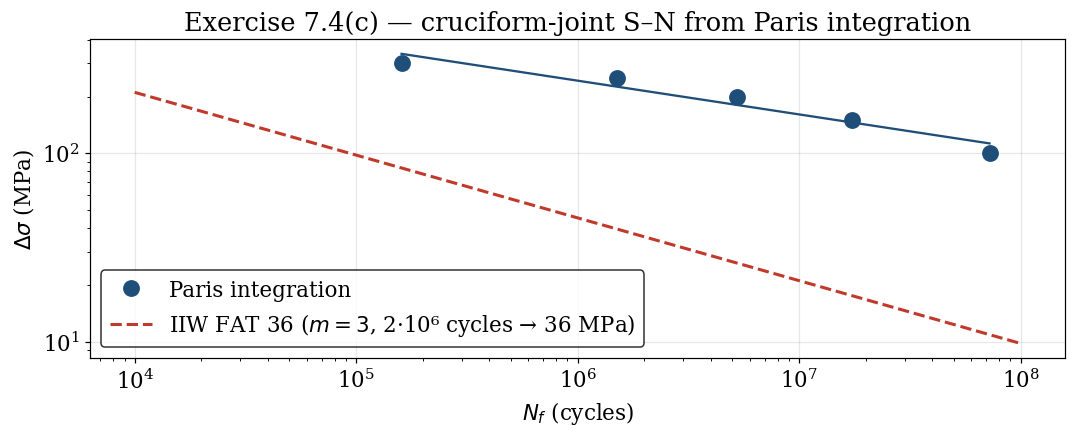

In [6]:
K_IC_Nmm = K_IC*SQRT1000

def integrate_weld(a0, dsigma, R, da=0.05):
    lo, hi = a0, 0.8*W
    for _ in range(80):
        mid = 0.5*(lo+hi)
        if K_max_Nmm(mid, dsigma, R) < K_IC_Nmm: lo = mid
        else:                                     hi = mid
    a_c = 0.5*(lo+hi)
    a, N = a0, 0.0
    while a < a_c:
        dK = Y_weld(a)*dsigma*np.sqrt(np.pi*a)
        dadN = C*dK**m
        step = min(da, a_c - a)
        N += step/dadN
        a += step
    return a_c, N

dsig_arr = np.array([100, 150, 200, 250, 300], dtype=float)
print(f'\n{"Δσ (MPa)":>10} {"a_c (mm)":>10} {"N_f (cycles)":>15}')
Nf_arr = []
for ds in dsig_arr:
    a_c, Nf = integrate_weld(a0, ds, R)
    Nf_arr.append(Nf)
    print(f'{ds:10.0f} {a_c:10.2f} {Nf:15.3e}')
Nf_arr = np.array(Nf_arr)

# Fit a Basquin power law to compare with FAT classes
slope, intercept = np.polyfit(np.log(Nf_arr), np.log(dsig_arr), 1)
print(f'\nFit:  log Δσ = {slope:.3f}·log N_f + {intercept:.3f}')
print(f'      Δσ = {np.exp(intercept):.1f} · N_f^{slope:+.3f}')
print(f'      Slope exponent m_SN = -1/slope = {-1/slope:.3f}  (Paris m was {m})')

# IIW FAT 36: 36 MPa at 2e6 cycles, slope m = 3
N_iiw = np.logspace(4, 8, 200)
ds_iiw = 36.0*(2e6/N_iiw)**(1/3)

fig, ax = plt.subplots()
ax.loglog(Nf_arr, dsig_arr, 'o', color=COLORS['curve'], markersize=10,
          label='Paris integration')
N_fit = np.logspace(np.log10(Nf_arr.min()), np.log10(Nf_arr.max()), 50)
ax.loglog(N_fit, np.exp(intercept)*N_fit**slope, '-', color=COLORS['curve'], lw=1.5)
ax.loglog(N_iiw, ds_iiw, '--', color=COLORS['point'], lw=2.0,
          label='IIW FAT 36 ($m=3$, 2·10⁶ cycles → 36 MPa)')
ax.set_xlabel(r'$N_f$ (cycles)'); ax.set_ylabel(r'$\Delta\sigma$ (MPa)')
ax.set_title('Exercise 7.4(c) — cruciform-joint S–N from Paris integration')
ax.legend(); plt.tight_layout(); plt.show()


#### Comment

The Paris-integrated S–N curve has a log-log slope $\approx -0.18$
(i.e. $m_\text{SN} \approx 5.6$), significantly steeper than the pure-Paris
prediction $-1/m = -1/3 \approx -0.33$. The reason is that the critical crack
length $a_c$ drops sharply as $\Delta\sigma$ increases (from 18.6 mm at
100 MPa down to 2.7 mm at 300 MPa), because $K_{\max}(a_c)=K_{IC}$ is
reached sooner; this geometry effect makes the S–N slope steeper than $-1/m$.

The predicted curve falls **above** the IIW FAT 36 line because the assumed
$a_0=2.5$ mm is comparable to a *single* real weld-root defect, while FAT 36
encompasses manufacturing scatter across many joints (larger defects, lack of
fusion, secondary bending) at a 95 % survival probability. Welded design in
practice uses the conservative IIW class; Paris integration reveals that the
*mean* behaviour can be substantially better than FAT 36.

#### Solution summary — Exercise 7.4

**(a)** $W = H + T_p = 65$ mm; $H/T_p = 0.30$; $A_1 \approx 1.2063$; $A_2 \approx 0.4096$.

**(b)–(c)**

| $\Delta\sigma$ (MPa) | $a_c$ (mm) | $N_f$ (cycles) |
|---:|---:|---:|
| 100 | 18.59 | $7.25 \times 10^7$ |
| 150 |  9.73 | $1.74 \times 10^7$ |
| 200 |  5.80 | $5.25 \times 10^6$ |
| 250 |  3.81 | $1.51 \times 10^6$ |
| 300 |  2.68 | $1.60 \times 10^5$ |

Log-log fit: slope $\approx -0.18$ ($m_\text{SN} \approx 5.6$). The Paris-integrated S–N curve lies above IIW FAT 36 — see comment above.

<a id='ex5'></a>
---

## Exercise 7.5 — Welded joints: concepts

(a) Fatigue of welded structures is fundamentally different from fatigue of non-welded structures. Mention two prominent differences.

(b) When designing against fatigue of welded joints, which aspects are most relevant?

(c) A connection between two parts of a dynamically loaded steel structure can be made as a welded joint or a bolted joint. How should this problem be handled from a fatigue perspective?

### Solution

**(a) Two prominent differences between welded and non-welded fatigue.**

1. **Initiation is irrelevant** in welded joints. Microscopic defects exist
   already at the weld toe / root (slag inclusions, undercuts, lack-of-fusion).
   Crack-growth life is essentially the *entire* fatigue life.
2. **Tensile residual stresses** at the weld toe ≈ $\sigma_e$. The local
   $R$-ratio is therefore close to 1 regardless of the nominal applied $R$,
   so welded S–N curves are **insensitive to $R$**. This is a fundamental
   difference from parent-material specimens.

**(b) What matters most in designing against fatigue of welds?**

* **Detail category** (geometric class) — Eurocode 3 / IIW classify joints
  by weld type, location, and direction of stress.
* **Quality of the weld surface** (no undercut, smooth toe blends, no
  spatter).
* **Stress range** $\Delta\sigma$ at the *hot spot*; mean stress is largely
  irrelevant in the as-welded state.
* **Residual stress relief** if relevant (post-weld heat treatment, peening,
  TIG dressing — these *do* shift the curve upward, but only if applied).
* **Inspection access** for in-service monitoring.

**(c) Welded vs bolted connection.**

Bolted (pre-tensioned, HSFG) connections behave like **non-welded** joints
under fatigue: high $K_{f}$ but no residual stresses → good $R$-sensitivity
and a well-defined fatigue limit. Welded connections are typically *cheaper*
but force the designer into the lower IIW FAT classes (no $R$-sensitivity,
no fatigue limit).

For a *dynamically loaded* steel structure with high cycles (bridge, offshore,
crane), the welded option is acceptable if the designer (i) selects a high
FAT class (smooth transitions, ground welds), (ii) keeps $\Delta\sigma$ low,
and (iii) plans NDI campaigns. If the operating $\Delta\sigma$ would force
a FAT class above 100, switching to a bolted connection is usually more
economical over the life of the structure.


---

### Final remarks

* Lugs, fretting and corrosion all share a single mechanism — **surface
  damage** under repeated micro-slip or chemical attack. Designing for
  fatigue requires designing for **surface integrity**.
* Welded joints are dominated by their **defect population** at the toe/root,
  and by **tensile residual stresses**. Modern hot-spot and structural-stress
  approaches (Niemi, Dong) try to *normalise* the FAT curve across geometries
  — they are the working tools of bridge and offshore design today.


---

Copyright (c) DEMI - NOVA FCT

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>

Parts of this notebook were prepared with AI assistance (<a href="https://www.anthropic.com/claude-code" target="_blank">Claude Code</a>, Anthropic), reviewed and verified by the author.